<a href="https://colab.research.google.com/github/Gautam-Chauhan/MSc-Thesis/blob/main/brute_force_gaussian_blue_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚠️ Warning

This is brute force gaussian blue noise. It has a quadratic complexity on N




## 📦 Install

- pip install numpy matplotlib

small N < 10_000 with jax

- CPU only: pip install jax["cpu"]
- GPU: pip install jax

### Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📥 Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import jax
import jax.numpy as jnp
from jax import lax

## 🎨 Plot utilities

In [3]:
def plot(points):
    pts = np.array(points)
    N, D = np.prod(pts.shape[:-1]), pts.shape[-1]

    if D == 2:
        pts = pts[..., :2]
    if D >= 3:
        pts = pts[..., :3]
        D = 3
    pts = pts.reshape(-1, D)

    if N > 30_000:
        ## zooming
        zoom = (30_000/N)**(1.0/D)
        pts = pts[
            (pts <= zoom).all(axis=-1)
        ]

    if D == 2:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=0.4,
            color="black",
        )
    else:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            s=0.4,
            color="black",
        )
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def integers_in_ball(radius, D):
    """3D integer vectors inside a sphere of given radius."""
    if radius <= 1.9:
        #here we don't need to build the grid, wich is crucial in high dimension
        return np.zeros((0, D), dtype = np.int32) if radius <= 0.9 else np.eye(D, dtype=np.int32)
    r = np.arange(-radius, radius + 1)
    xyz = np.stack(
        np.meshgrid(*(r,) * D, indexing="ij"), axis=-1
    ).reshape(-1, D)
    xyz_len = np.sum(xyz ** 2, axis=-1)
    return xyz[(xyz_len > 0) & (xyz_len <= radius ** 2)]

def structure_factor(
    points,
    bins = 100,
    resolution=1,
):
    """ structure factor estimated through scattering intensity """
    pts = np.asarray(points)
    N, D = pts.shape

    kmed = int(1000**(1/D))
    kmax = int(2 * N**(1.0/D))

    bins = np.linspace(0, kmax, bins)
    n_bins = len(bins) - 1

    nvecs = np.random.randint(
        -kmax,
        kmax + 1,
        size=(int(resolution*1000), D),
    )

    nvecs = np.concatenate(
        [nvecs, integers_in_ball(kmed, D)],
        axis=0,
    )

    nvecs = nvecs[np.any(nvecs != 0, axis=1)]

    knorm = np.linalg.norm(nvecs, axis=1)

    bin_idx = np.searchsorted(bins, knorm) - 1

    valid = (bin_idx >= 0) & (bin_idx < n_bins)
    nvecs   = nvecs[valid]
    bin_idx = bin_idx[valid]

    kvecs = 2.0 * np.pi * nvecs

    pts   = jnp.array(pts)
    kvecs = jnp.array(kvecs)

    def compute_Sk(k):
        rho = jnp.sum(jnp.exp(1j * (pts @ k)), axis=0)
        return jnp.abs(rho) ** 2 / N

    Sk = jax.lax.map(compute_Sk, kvecs)

    Sk = np.asarray(Sk)

    S = np.bincount(bin_idx, weights=Sk, minlength=n_bins)
    C = np.bincount(bin_idx,             minlength=n_bins)

    valid = C > 0
    S = S[valid] / C[valid]
    k = (0.5 * (bins[:-1] + bins[1:]))[valid]

    return k, S


def plot_sf(x, bins = 100, resolution = 1):
    x = x.reshape(-1, x.shape[-1])

    ks, vals = structure_factor(x)

    plt.figure()
    plt.loglog(ks, vals, marker="o", markersize=2, linewidth=1)
    plt.xlabel("k"); plt.ylabel("S(k)")
    plt.title("Structure factor (log-log)")
    plt.grid(True, which="both"); plt.tight_layout(); plt.show()

## 🏭 Optimizaton pipeline

In [4]:
def _make_hyperparams(N, D, custom_lr):
    """Shared hyperparameter logic."""
    DX = 1 / N ** (1.0 / D)
    S = 1
    sigma2 = S * 2 * DX ** 2
    high_dimension_regime = sigma2 >= 0.03

    if D <= 2:   lr = 0.4
    elif D == 3: lr = 0.1
    elif D == 4: lr = 0.05
    elif D == 5: lr = 0.02
    else:        lr = custom_lr

    Niter = 10_000 if not high_dimension_regime else 1_000

    a_ = 2.0 * jnp.pi
    b_ = 2.0 / (sigma2 * a_ ** 2)
    c_ = 1.0 / (2 * S * jnp.pi)

    return sigma2, lr, Niter, high_dimension_regime, a_, b_, c_


def _make_kernels(sigma2, high_dimension_regime, a_, b_, c_,verbose):
    """Build pacman + both kernels, return the selected one."""

    def pacman(x):
        return x - jnp.floor(x)

    def gaussian_kernel(x, y):
        delta = pacman(y - x + 0.5) - 0.5
        dist2 = jnp.sum(delta**2, axis = -1, keepdims = True)
        return delta * jnp.exp(-dist2 / sigma2)

    def gaussian_sinus_kernel(x, y):
        delta = a_ * (y - x)
        cos_term = b_ * (1.0 - jnp.cos(delta))
        sin_term = c_ * jnp.sin(delta)
        dist2 = jnp.sum(cos_term, axis = -1, keepdims = True)
        return sin_term * jnp.exp(-dist2)

    if verbose:
      print("available kernels [gaussian / gaussian_sine]")

    if high_dimension_regime:

        if verbose:
          print(f"selected [gaussian_sine] as sigma2={sigma2:.3f} >= 0.03")
        return pacman, gaussian_sinus_kernel
    else:
        if verbose:
          print(f"selected [gaussian] as sigma2={sigma2:.3f} < 0.03")
        return pacman, gaussian_kernel


# ───────────────────
# gradient descent
# ───────────────────
def make_pipeline(N, D, custom_lr,verbose):
    sigma2, lr, Niter, high_dim, a_, b_, c_ = _make_hyperparams(N, D, custom_lr)
    pacman, kernel = _make_kernels(sigma2, high_dim, a_, b_, c_,verbose)

    def grad(x):
        return kernel(x[:, None], x[None, :]).sum(axis=1)

    @jax.jit
    def run_n_steps(x):
        def step(i, x):
            return pacman(x - lr * grad(x))
        return jax.lax.fori_loop(0, Niter, step, x)

    if verbose:
      print("Compiling pipeline...")
    compiled_run = run_n_steps.lower(
        jax.ShapeDtypeStruct((N, D), jnp.float32)
    ).compile()
    if verbose:
      print("Done. Pipeline ready.")

    def sample(init=None):
        """Sample a stealthy point pattern. Best for N ≤ 3000."""
        if init is None:
            init = np.random.rand(N, D)
        init = jnp.asarray(init)
        result = compiled_run(init)
        result.block_until_ready()
        return result

    return sample

## 🏁 Entry point:

- N: number of points \
DON'T go beyond **a few thousand points** because brute_force has quadratic complexity

- D: dimension of the points \
feel free to go **up to dimension 100**

In [42]:
N = 665
D = 7

pipeline = make_pipeline(N, D, custom_lr=0.0025)

available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.091 >= 0.03
Compiling pipeline...
Done. Pipeline ready.


## 🔥 Let's go !

In [43]:
Poisson = np.random.rand(N, D)
start = time.time()
stealthy_points = pipeline(init = Poisson)
end = time.time()
print(f"stealthy points ready (runtime {(end-start):.1f} s)")

KeyboardInterrupt: 

benchmark: D = 4
gaussian sine kernel
1000 iterations

GPU Colab 15 Giga JAX

100 points = 0.01 s \
200 points = 0.01 s \
500 points = 0.02 s \
1000 points = 0.08 s \
2000 points = 0.3 s \
5000 points = 2.5 s \
10_000 points = 12 s \
20_000 points = 50 s \
50_000 points = 350 s \
100_000 points: Jax DEAD out of memory \

GPU Colab 15 Giga KeOps

100 points = 1.5 s \
200 points = 3.3 s \
500 points = 7.2 s \
1000 points = 14 s \
2000 points = 27 s \
5000 points = 66 s \
10_000 points = 256 s \
20_000 points = 770 s \
50_000 points:  = 4500 s \
100_000 points = 18000 s \

## 🖼️ Result

D = 7, N = 32768, lr = 0.0025

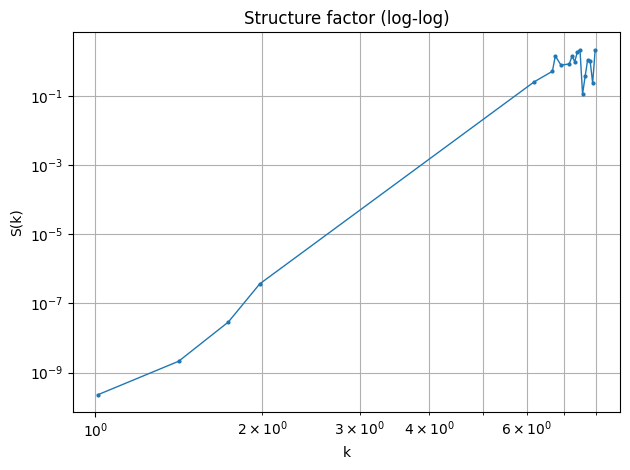

In [37]:
plot_sf(stealthy_points, bins = 100, resolution = 1)

## Experiments to test out learning rate in different dimensions:

**Dimension 6**

In [28]:
learning_rates = [0.01, 0.005, 0.0025, 0.001]
set_sizes = [4096, 8192, 16384, 32768]
D = 6

In [29]:
min_structure_factors = []
point_sets = []
for lr in learning_rates:
  for N in set_sizes:
    print(f"Starting learning_rate = {lr} and N = {N}")
    pipeline = make_pipeline(N, D, custom_lr=lr)
    Poisson = np.random.rand(N, D)
    stealthy_points = pipeline(init=Poisson)
    point_sets.append(stealthy_points)
    ks, vals = structure_factor(stealthy_points)
    min_structure_factors.append(np.min(vals))

Starting learning_rate = 0.01 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.125 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.01 and N = 8192
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.099 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.01 and N = 16384
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.079 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.01 and N = 32768
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.063 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.005 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.125 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.005 and N = 8192
available kernels [gaussian / gaussian_sine]
sel

Text(0.5, 1.0, 'Depth of Structure Factor for D=6')

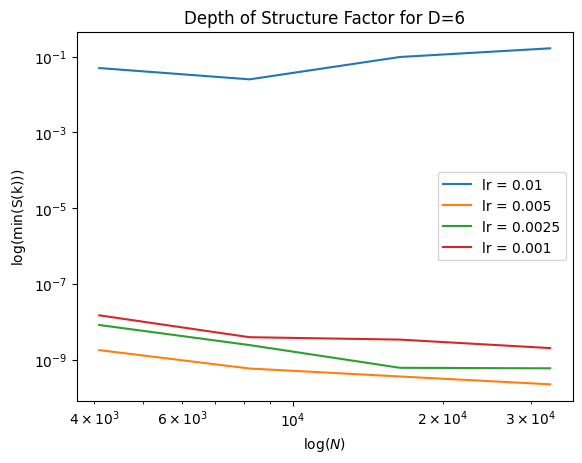

In [30]:
min_structure_factors_array = np.array(min_structure_factors)
min_structure_factors_array = min_structure_factors_array.reshape(len(learning_rates),len(set_sizes))

for i in range(len(learning_rates)):
  plt.loglog(set_sizes, min_structure_factors_array[i,:],label=f"lr = {learning_rates[i]}")
plt.legend()
plt.xlabel(r"$\log(N)$")
plt.ylabel(r"$\log(\text{min(S(k))})$")
plt.title("Depth of Structure Factor for D=6")

In [33]:
learning_rates = [0.01, 0.005, 0.0025, 0.001]
set_sizes = [4096, 8192, 16384, 32768]
D = 7

In [34]:
min_structure_factors = []
point_sets = []
for lr in learning_rates:
  for N in set_sizes:
    print(f"Starting learning_rate = {lr} and N = {N}")
    pipeline = make_pipeline(N, D, custom_lr=lr)
    Poisson = np.random.rand(N, D)
    stealthy_points = pipeline(init=Poisson)
    point_sets.append(stealthy_points)
    ks, vals = structure_factor(stealthy_points)
    min_structure_factors.append(np.min(vals))

Starting learning_rate = 0.01 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.186 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.01 and N = 8192
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.152 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.01 and N = 16384
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.125 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.01 and N = 32768
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.103 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.005 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.186 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.005 and N = 8192
available kernels [gaussian / gaussian_sine]
sel

Text(0.5, 1.0, 'Depth of Structure Factor for D=7')

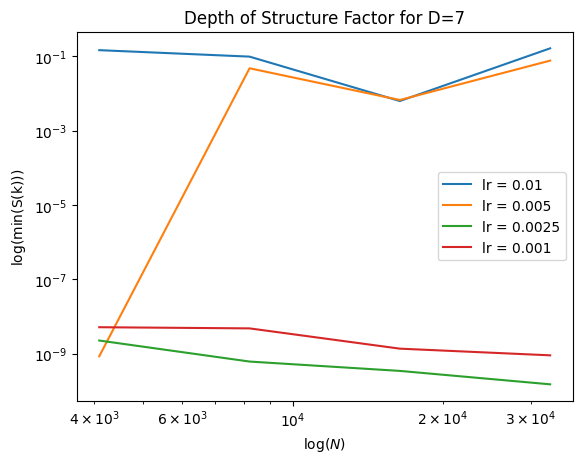

In [37]:
min_structure_factors_array = np.array(min_structure_factors)
min_structure_factors_array = min_structure_factors_array.reshape(len(learning_rates),len(set_sizes))

for i in range(len(learning_rates)):
  plt.loglog(set_sizes, min_structure_factors_array[i,:],label=f"lr = {learning_rates[i]}")
plt.legend()
plt.xlabel(r"$\log(N)$")
plt.ylabel(r"$\log(\text{min(S(k))})$")
plt.title("Depth of Structure Factor for D=7")

**Dimension 8**

In [8]:
learning_rates = [0.0025, 0.001, 0.0005, 0.00025]
set_sizes = [4096, 8192, 16384, 32768]
D = 8

In [11]:
min_structure_factors = []
point_sets = []
for lr in learning_rates:
  for N in set_sizes:
    print(f"Starting learning_rate = {lr} and N = {N}")
    pipeline = make_pipeline(N, D, custom_lr=lr)
    Poisson = np.random.rand(N, D)
    stealthy_points = pipeline(init=Poisson)
    point_sets.append(stealthy_points)
    ks, vals = structure_factor(stealthy_points)
    min_structure_factors.append(np.min(vals))

Starting learning_rate = 0.0025 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.250 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.0025 and N = 8192
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.210 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.0025 and N = 16384
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.177 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.0025 and N = 32768
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.149 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.001 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.250 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.001 and N = 8192
available kernels [gaussian / gaussian_s

In [13]:
min_structure_factors_array = np.array(min_structure_factors)
min_structure_factors_array = min_structure_factors_array.reshape(len(learning_rates),len(set_sizes))

Text(0.5, 1.0, 'Depth of Structure Factor for D=8')

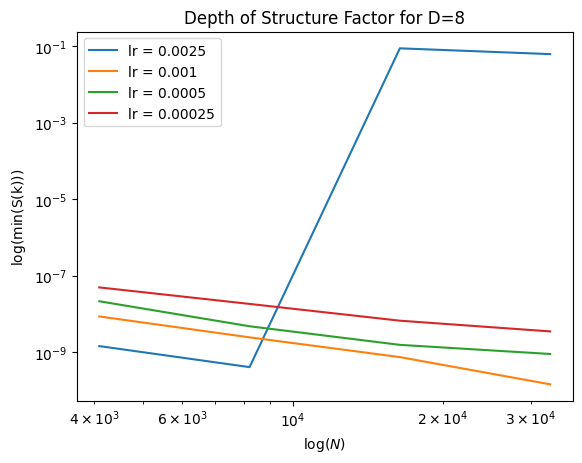

In [20]:
for i in range(len(learning_rates)):
  plt.loglog(set_sizes, min_structure_factors_array[i,:],label=f"lr = {learning_rates[i]}")
plt.legend()
plt.xlabel(r"$\log(N)$")
plt.ylabel(r"$\log(\text{min(S(k))})$")
plt.title("Depth of Structure Factor for D=8")

Learning Rate = 0.001 and 32768 points:

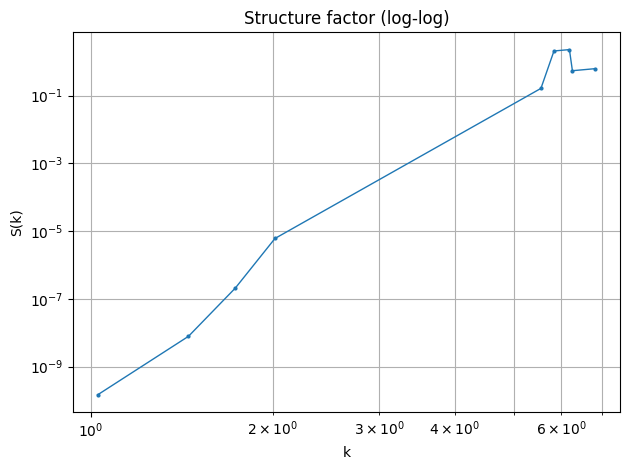

In [23]:
plot_sf(point_sets[7], bins = 100, resolution = 1)

In [24]:
learning_rates = [0.0025, 0.001, 0.0005, 0.00025]
set_sizes = [4096, 8192, 16384, 32768]
D = 9

In [25]:
min_structure_factors = []
point_sets = []
for lr in learning_rates:
  for N in set_sizes:
    print(f"Starting learning_rate = {lr} and N = {N}")
    pipeline = make_pipeline(N, D, custom_lr=lr)
    Poisson = np.random.rand(N, D)
    stealthy_points = pipeline(init=Poisson)
    point_sets.append(stealthy_points)
    ks, vals = structure_factor(stealthy_points)
    min_structure_factors.append(np.min(vals))

Starting learning_rate = 0.0025 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.315 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.0025 and N = 8192
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.270 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.0025 and N = 16384
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.231 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.0025 and N = 32768
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.198 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.001 and N = 4096
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.315 >= 0.03
Compiling pipeline...
Done. Pipeline ready.
Starting learning_rate = 0.001 and N = 8192
available kernels [gaussian / gaussian_s

Text(0.5, 1.0, 'Depth of Structure Factor for D=9')

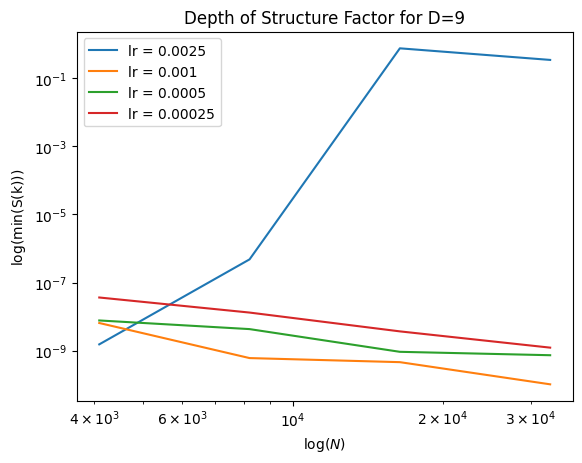

In [26]:
min_structure_factors_array = np.array(min_structure_factors)
min_structure_factors_array = min_structure_factors_array.reshape(len(learning_rates),len(set_sizes))

for i in range(len(learning_rates)):
  plt.loglog(set_sizes, min_structure_factors_array[i,:],label=f"lr = {learning_rates[i]}")
plt.legend()
plt.xlabel(r"$\log(N)$")
plt.ylabel(r"$\log(\text{min(S(k))})$")
plt.title("Depth of Structure Factor for D=9")

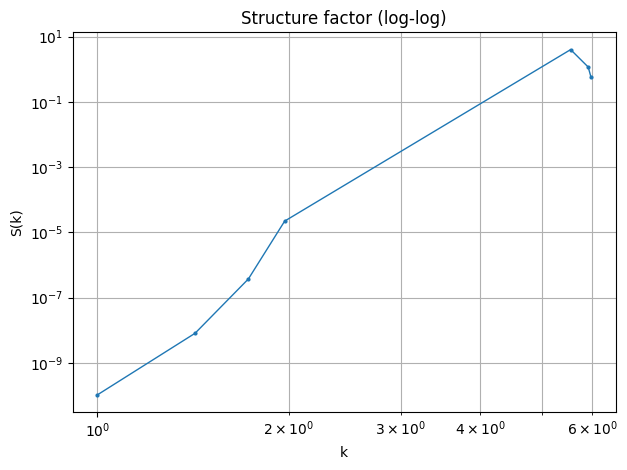

In [27]:
plot_sf(point_sets[7], bins = 100, resolution = 1)

Learning Rates for different dimensions (>5):

Dimension 6: 0.01

Dimension 7: 0.0025

Dimension 8: 0.001

Dimension 9: 0.001

## Generate GBN point sets in up to 9D using new learning rates

In [5]:
dimensions = [2,3,4,5]
set_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runtimes = np.empty((len(set_sizes),len(dimensions)))

In [6]:
for i in range(len(set_sizes)):
  for j in range(len(dimensions)):
    blue_noise_points = np.empty((10,set_sizes[i],dimensions[j]))
    local_runtimes = []
    for k in range(10):
      rng = np.random.default_rng(seed=k)
      uniform_points = rng.uniform(size=(set_sizes[i],dimensions[j]))
      start_time = time.time()
      # Set custom_lr = None because we use the default learning rate for D <= 5
      pipeline = make_pipeline(set_sizes[i], dimensions[j], custom_lr=None,verbose=False)
      point_set = pipeline(init=uniform_points)
      end_time = time.time()
      local_runtimes.append(end_time-start_time)
      blue_noise_points[k,:,:] = point_set
    runtimes[i,j] = np.mean(local_runtimes)
    print("\n")
    print(f"Done size {set_sizes[i]} and dimension {dimensions[j]}")
    np.save(f"/content/drive/MyDrive/gaussian_blue_noise/blue_noise_points/blue_noise_{set_sizes[i]}_{dimensions[j]}",blue_noise_points)



Done size 64 and dimension 2


Done size 64 and dimension 3


Done size 64 and dimension 4


Done size 64 and dimension 5


Done size 128 and dimension 2


Done size 128 and dimension 3


Done size 128 and dimension 4


Done size 128 and dimension 5


Done size 256 and dimension 2


Done size 256 and dimension 3


Done size 256 and dimension 4


Done size 256 and dimension 5


Done size 512 and dimension 2


Done size 512 and dimension 3


Done size 512 and dimension 4


Done size 512 and dimension 5


Done size 1024 and dimension 2


Done size 1024 and dimension 3


Done size 1024 and dimension 4


Done size 1024 and dimension 5


Done size 2048 and dimension 2


Done size 2048 and dimension 3


Done size 2048 and dimension 4


Done size 2048 and dimension 5


Done size 4096 and dimension 2


Done size 4096 and dimension 3


Done size 4096 and dimension 4


Done size 4096 and dimension 5


Done size 8192 and dimension 2


Done size 8192 and dimension 3


Done size 8192 and dimension

In [14]:
dimensions = [6,7,8,9]
learning_rates = [0.01,0.0025,0.001,0.001]
set_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runtimes = np.empty((len(set_sizes),len(dimensions)))

In [16]:
for i in range(len(set_sizes)):
  for j in range(len(dimensions)):
    blue_noise_points = np.empty((10,set_sizes[i],dimensions[j]))
    local_runtimes = []
    for k in range(10):
      rng = np.random.default_rng(seed=k)
      uniform_points = rng.uniform(size=(set_sizes[i],dimensions[j]))
      start_time = time.time()
      pipeline = make_pipeline(set_sizes[i], dimensions[j], custom_lr=learning_rates[j],verbose=False)
      point_set = pipeline(init=uniform_points)
      end_time = time.time()
      local_runtimes.append(end_time-start_time)
      blue_noise_points[k,:,:] = point_set
    runtimes[i,j] = np.mean(local_runtimes)
    print("\n")
    print(f"Done size {set_sizes[i]} and dimension {dimensions[j]}")
    np.save(f"/content/drive/MyDrive/gaussian_blue_noise/blue_noise_points/blue_noise_{set_sizes[i]}_{dimensions[j]}",blue_noise_points)



Done size 64 and dimension 6


Done size 64 and dimension 7


Done size 64 and dimension 8


Done size 64 and dimension 9


Done size 128 and dimension 6


Done size 128 and dimension 7


Done size 128 and dimension 8


Done size 128 and dimension 9


Done size 256 and dimension 6


Done size 256 and dimension 7


Done size 256 and dimension 8


Done size 256 and dimension 9


Done size 512 and dimension 6


Done size 512 and dimension 7


Done size 512 and dimension 8


Done size 512 and dimension 9


Done size 1024 and dimension 6


Done size 1024 and dimension 7


Done size 1024 and dimension 8


Done size 1024 and dimension 9


Done size 2048 and dimension 6


Done size 2048 and dimension 7


Done size 2048 and dimension 8


Done size 2048 and dimension 9


Done size 4096 and dimension 6


Done size 4096 and dimension 7


Done size 4096 and dimension 8


Done size 4096 and dimension 9


Done size 8192 and dimension 6


Done size 8192 and dimension 7


Done size 8192 and dimension

In [17]:
np.save("/content/drive/MyDrive/gaussian_blue_noise/blue_noise_points/runtimes.npy",runtimes)

In [4]:
blue_noise_points = np.load("/content/drive/MyDrive/gaussian_blue_noise/blue_noise_points/blue_noise_32768_9.npy")

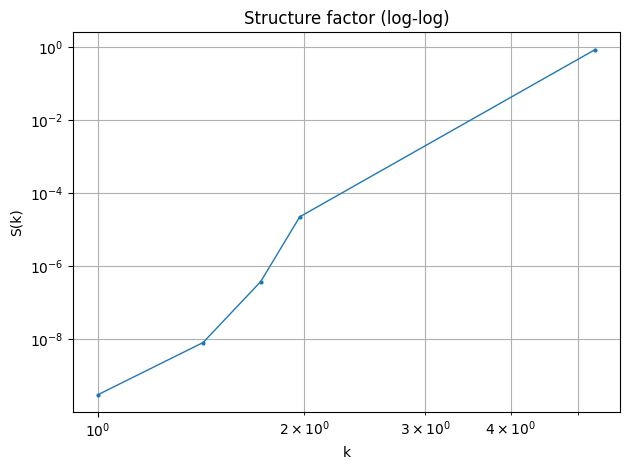

In [5]:
point_set = blue_noise_points[5,:,:]
plot_sf(point_set)

Plot runtimes for the different dimensions to confirm quadratic dependence on number of points:

In [6]:
runtimes = np.load("/content/drive/MyDrive/gaussian_blue_noise/blue_noise_points/runtimes.npy")

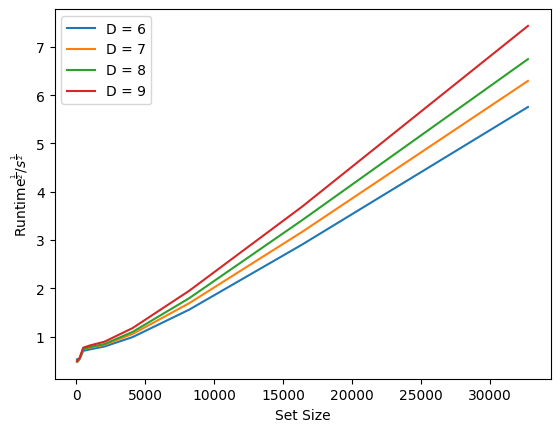

In [13]:
dimensions = [6,7,8,9]
set_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
for i in range(len(dimensions)):
  plt.plot(set_sizes, np.sqrt(runtimes[:,i]),label=f"D = {dimensions[i]}")
plt.xlabel("Set Size")
plt.ylabel(r"$\text{Runtime}^{\frac{1}{2}}/s^{\frac{1}{2}}$")
plt.legend()